# Dataset folder structure
```
data/
│
├── images/                              # PNG files
│   ├── 0.png                           
│   │   .
│   │   .
│   │   .
│   └── 1.png                          
│
└── labels.json                                # json dict of files


In [1]:
from pathlib import Path

MODEL='Kuzushiji'

EPOCHS=1

LR=1e-4

PREPROCESS_DATA = False

USE_CHECKPOINT = True

DATASET_PATH = Path('preprocessed_data/text_renderer')

VERTICAL_DATASET_PATH = Path('preprocessed_data/text_renderer_vertical')

DATASET_PATH.mkdir(parents=True, exist_ok=True)

AUGMENT_DATA = False


In [2]:
import json
from pathlib import Path
from util.data_processing import split_dataset

if PREPROCESS_DATA:
    split_dataset(DATASET_PATH)
    split_dataset(VERTICAL_DATASET_PATH)

/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import json
if AUGMENT_DATA:
    with open(str(DATASET_PATH / 'train_labels.json'), 'r') as fp:
        data_dict = json.load(fp)

    print(f"{len(data_dict.items())} dict elements")

In [4]:
from util.augmentation import augment_dataset
from util.data_processing import save_labels

(DATASET_PATH/'images'/'augmented').mkdir(parents=True, exist_ok=True)
if AUGMENT_DATA:
    augment_dataset(data_dict, 3, 3, 3, str(DATASET_PATH / 'images')+'/')
    save_labels(data_dict, DATASET_PATH / 'augmented_labels.json')

In [5]:
import json
if AUGMENT_DATA:
    with open(str(VERTICAL_DATASET_PATH / 'train_labels.json'), 'r') as fp:
        data_dict = json.load(fp)

    print(f"{len(data_dict.items())} dict elements")

In [6]:
from util.augmentation import augment_dataset
from util.data_processing import save_labels

(VERTICAL_DATASET_PATH/'images'/'augmented').mkdir(parents=True, exist_ok=True)
if AUGMENT_DATA:
    augment_dataset(data_dict, 3, 3, 3, str(VERTICAL_DATASET_PATH / 'images')+'/')
    save_labels(data_dict, VERTICAL_DATASET_PATH / 'augmented_labels.json')

In [7]:
import json
from pathlib import Path

with open(str(DATASET_PATH / 'augmented_labels.json'), 'r') as fp:
    data_dict = json.load(fp)

tr_dict = dict()

for items in data_dict.items():
    tr_dict[str(DATASET_PATH / 'images' / items[0]) + '.jpg'] = items[1]


with open(str(VERTICAL_DATASET_PATH / 'augmented_labels.json'), 'r') as fp:
    data_dict = json.load(fp)

vertical_dict = dict()

for items in data_dict.items():
    vertical_dict[str(VERTICAL_DATASET_PATH / 'images' / items[0]) + '.jpg'] = items[1]


# # with open(str(Path('preprocessed_data/text_renderer_print') / 'augmented_labels.json'), 'r') as fp:
# #     data_dict = json.load(fp)

# # print_dict = dict()

# # for items in data_dict.items():
# #     print_dict[str(Path('preprocessed_data/text_renderer_vertical') / 'images' / items[0]) + '.jpg'] = items[1]

print(f"{len(tr_dict.items())} dict elements")

words_files = list(tr_dict.items()) + list(vertical_dict.items())
print(f"{len(words_files)} dict elements")
print(words_files[0])

7200000 dict elements
14400000 dict elements
('preprocessed_data/text_renderer/images/001031684.jpg', 'がっているもの')


In [8]:
import json
from pathlib import Path

with open(str(DATASET_PATH / 'test_labels.json'), 'r') as fp:
    data_dict = json.load(fp)

tr_dict = dict()

for items in data_dict.items():
    tr_dict[str(DATASET_PATH / 'images' / items[0]) + '.jpg'] = items[1]


with open(str(VERTICAL_DATASET_PATH / 'test_labels.json'), 'r') as fp:
    data_dict = json.load(fp)

vertical_dict = dict()

for items in data_dict.items():
    vertical_dict[str(VERTICAL_DATASET_PATH / 'images' / items[0]) + '.jpg'] = items[1]


print(f"{len(tr_dict.items())} dict elements")

test_word_files = list(tr_dict.items()) + list(vertical_dict.items())
print(f"{len(words_files)} dict elements")
print(test_word_files[0])

200000 dict elements
14400000 dict elements
('preprocessed_data/text_renderer/images/001642525.jpg', 'す。運転免許')


In [9]:
from util.data_processing import get_words_list


train_words = get_words_list(words_files)
test_words = get_words_list(test_word_files)
print(f'Train size: {len(train_words)}; Test size: {len(test_words)}')
print(train_words[0], test_words[0])

Building dataset: 100%|██████████| 14400000/14400000 [37:01<00:00, 6481.73it/s] 


Word(file_path='preprocessed_data/text_renderer/images/augmented/001000353-2.jpg', transcription='してお前')


Building dataset: 100%|██████████| 400000/400000 [01:04<00:00, 6220.67it/s]


Word(file_path='preprocessed_data/text_renderer/images/001544966.jpg', transcription='、逆')
Train size: 14400000; Test size: 400000
Word(file_path='preprocessed_data/text_renderer/images/augmented/001000353-2.jpg', transcription='してお前') Word(file_path='preprocessed_data/text_renderer/images/001544966.jpg', transcription='、逆')


In [10]:
print(train_words[1], test_words[1])

Word(file_path='preprocessed_data/text_renderer_vertical/images/augmented/000503549-0.jpg', transcription='肉') Word(file_path='preprocessed_data/text_renderer/images/000895795.jpg', transcription='して、記憶が')


# Build dataset and dataloader

In [11]:
from util.data_processing import WORDSDataset
from dtrocr.config import DTrOCRConfig

config = DTrOCRConfig(max_position_embeddings=512
    # attn_implementation='flash_attention_2'
)
train_data = WORDSDataset(words=train_words, config=config)
test_data = WORDSDataset(words=test_words, config=config)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [12]:
from torch.utils.data import DataLoader
import multiprocessing as mp
from util.data_processing import WordsSampler

i = 0

if USE_CHECKPOINT and Path(f'{MODEL} train_samp_ind.txt').exists():
    with open(f'{MODEL} train_samp_ind.txt', 'r') as f:
        i = int(f.readline())
        print(i)
sampler = WordsSampler(train_data, i = i)
print(sampler.seq[0])


    

train_dataloader = DataLoader(train_data, batch_size=32, sampler=sampler, shuffle=False, num_workers=mp.cpu_count())
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=mp.cpu_count())

0


# Model

In [13]:
from util.model import get_model

model = get_model(config, MODEL)

# Training

In [ ]:
from util.model import train

train(model, train_dataloader, test_dataloader, EPOCHS, MODEL, LR, 'Text Renderer')

Epoch 1:   2%|▏         | 10000/450000 [3:55:16<308:17:50,  2.52s/it]

Train loss: 5.541909814357758, Train accuracy: 0.28781218647956847


Epoch 1:   4%|▍         | 20000/450000 [7:49:44<285:40:20,  2.39s/it]

Train loss: 5.389360577440262, Train accuracy: 0.29590921186581254


Epoch 1:   6%|▌         | 26343/450000 [11:34:03<186:02:00,  1.58s/it]  


# Test

In [ ]:
from dtrocr.model import DTrOCRLMHeadModel
from dtrocr.config import DTrOCRConfig
from dtrocr.processor import DTrOCRProcessor
import torch
torch.save(model.state_dict(), f'../models/{MODEL}.pt')
# model = DTrOCRLMHeadModel(DTrOCRConfig())
model.eval()
model.to('cpu')
test_processor = DTrOCRProcessor(DTrOCRConfig())

/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/dtrocr-0.3.0-py3.12.egg/dtrocr/model.py:295: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  next_tokens = torch.argmax(torch.nn.functional.softmax(next_token_scores), dim=-1)


Ответ:  た。いかがでし  Вывод модели:  た。いかがでし


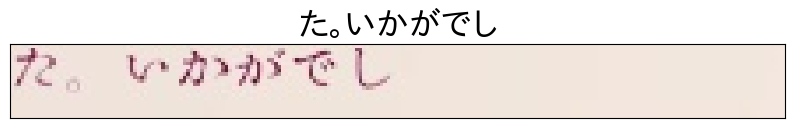

Ответ:  した。  Вывод модели:  した。


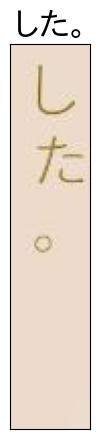

Ответ:  い  Вывод модели:  い


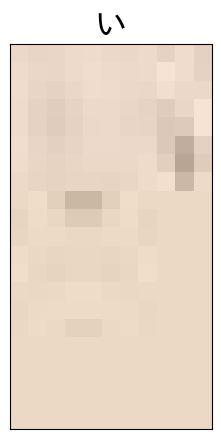

Ответ:  用  Вывод модели:  用


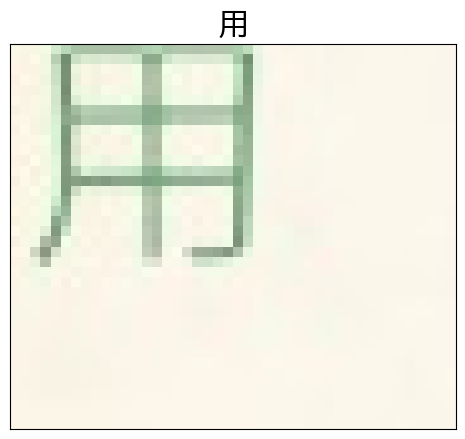

Ответ:  そうしたらま  Вывод модели:  そうしたらら


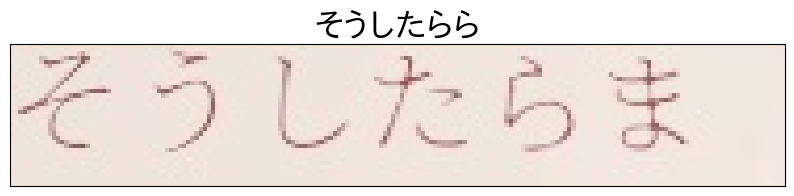

Ответ:  いに可愛らし  Вывод модели:  いに可愛


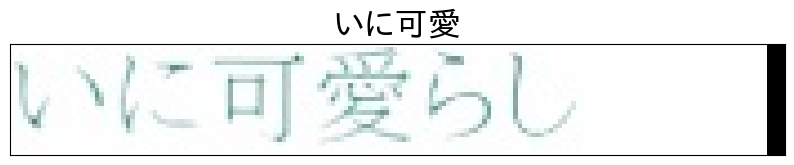

Ответ:  ぼう  Вывод модели:  ぼ


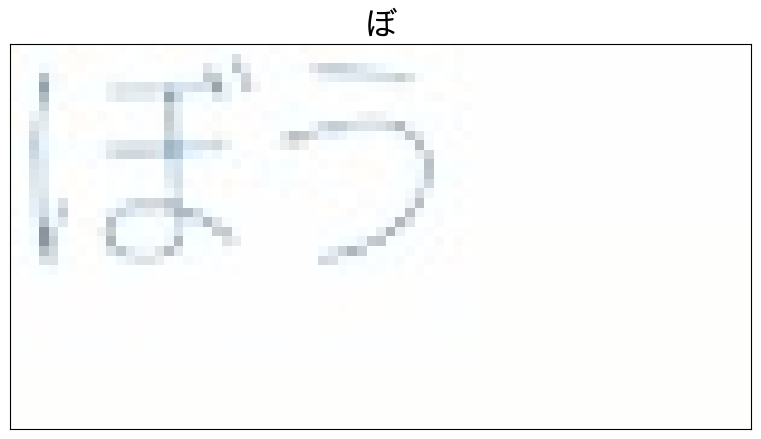

Ответ:  いで、  Вывод модели:  いで、


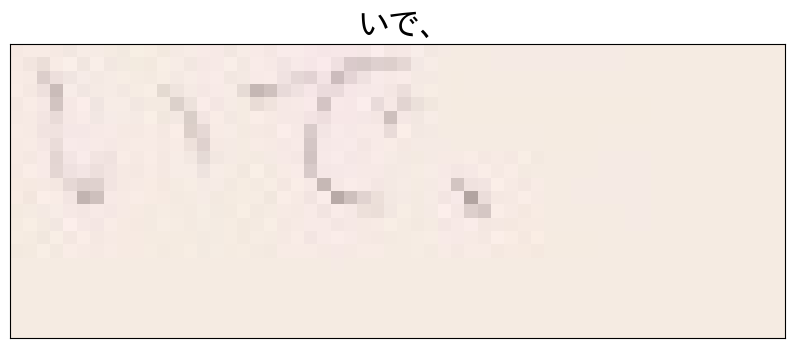

Ответ:  た様な  Вывод модели:  た様な


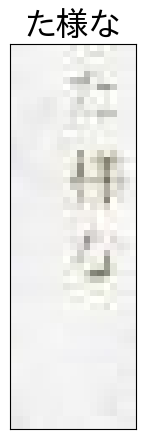

Ответ:  ということで  Вывод модели:  きよう。


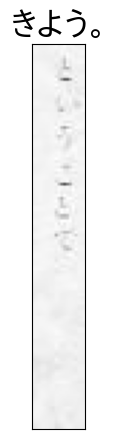

In [ ]:
from util.model import test

test(model, train_words, 10)